In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('UK_Stock_Market_2024_Onwards.csv')
df.head()

,Unnamed: 0,Date,Ticker,Company_Name,Open,High,Low,Close,Adj Close,Volume
0,433,2024-01-02,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.790,4.50,4.6,4.6,13557.0
1,434,2024-01-03,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.600,4.60,4.6,4.6,0.0
2,435,2024-01-04,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.700,4.59,4.6,4.6,37422.0
3,436,2024-01-05,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.575,4.50,4.5,4.5,225823.0
4,437,2024-01-08,1SN.L,FIRST TIN PLC ORD GBP0.001,4.5,4.530,4.34,4.5,4.5,154905.0


In [3]:
df.tail()

,Unnamed: 0,Date,Ticker,Company_Name,Open,High,Low,Close,Adj Close,Volume
101330,4403208,2024-05-16,ZYT.L,ZYTRONIC ORD GBP0.01,56.5,60.000000,55.000000,57.5,57.5,1837.0
101331,4403209,2024-05-17,ZYT.L,ZYTRONIC ORD GBP0.01,57.5,57.750000,57.750000,57.5,57.5,25000.0
101332,4403210,2024-05-20,ZYT.L,ZYTRONIC ORD GBP0.01,57.5,56.099998,55.000000,57.5,57.5,8089.0
101333,4403211,2024-05-21,ZYT.L,ZYTRONIC ORD GBP0.01,57.5,58.884998,58.884998,57.5,57.5,6369.0
101334,4403212,2024-05-22,ZYT.L,ZYTRONIC ORD GBP0.01,57.5,58.500000,56.099998,57.5,57.5,3904.0


In [4]:
close=df.reset_index()['Close']
close

0          4.6
1          4.6
2          4.6
3          4.5
4          4.5
          ... 
101330    57.5
101331    57.5
101332    57.5
101333    57.5
101334    57.5
Name: Close, Length: 101335, dtype: float64

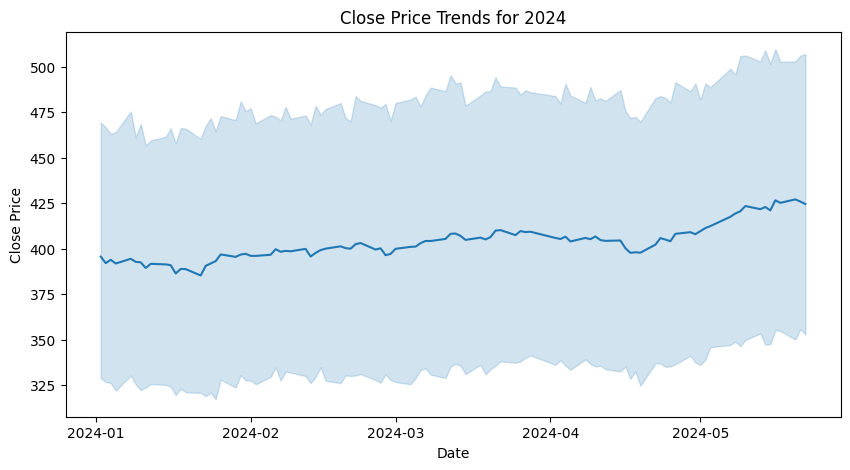

In [5]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Filter the dataframe for the year 2024
df_2024 = df[df['Date'].dt.year == 2024]

# Create the line plot for the year 2024
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_2024, x='Date', y='Close')
plt.title('Close Price Trends for 2024')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [6]:
# Check for NaNs/Infs in data
print("NaNs in data:", np.isnan(close).any())
print("Infs in data:", np.isinf(close).any())

NaNs in data: True
Infs in data: False


In [7]:
import numpy as np
close = close.fillna(close.mean())

print("NaNs in data after filling:", np.isnan(close).any())

NaNs in data after filling: False


In [8]:
df['Close'] = df['Close'].fillna(df['Close'].mean())

# Then proceed with the rest of your data processing...
numeric_df = df.copy()
datetime_columns = numeric_df.select_dtypes(include=['datetime64']).columns
for col in datetime_columns:
    numeric_df[col] = numeric_df[col].astype(np.int64) // 10**9  # Convert to Unix timestamp
    
numeric_df = numeric_df.select_dtypes(include=['int64', 'float64'])

X = numeric_df.drop('Close', axis=1)
y = numeric_df['Close']

In [9]:
# import train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Perform train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Checking Nan in X_train, y_train, X_test, y_test
print("NaNs in X_train:", np.isnan(X_train).any())
print("NaNs in y_train:", np.isnan(y_train).any())
print("NaNs in X_test:", np.isnan(X_test).any())
print("NaNs in y_test:", np.isnan(y_test).any())

NaNs in X_train: Unnamed: 0    False
Date          False
Open           True
High           True
Low            True
Adj Close      True
Volume         True
dtype: bool
NaNs in y_train: False
NaNs in X_test: Unnamed: 0    False
Date          False
Open           True
High           True
Low            True
Adj Close      True
Volume         True
dtype: bool
NaNs in y_test: False


In [11]:
# Filling NaNs with mean
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_test.mean())
# Checking NaN after filling
print("NaNs in X_train after filling:", np.isnan(X_train).any())
print("NaNs in y_train after filling:", np.isnan(y_train).any())
print("NaNs in X_test after filling:", np.isnan(X_test).any())
print("NaNs in y_test after filling:", np.isnan(y_test).any())

NaNs in X_train after filling: Unnamed: 0    False
Date          False
Open          False
High          False
Low           False
Adj Close     False
Volume        False
dtype: bool
NaNs in y_train after filling: False
NaNs in X_test after filling: Unnamed: 0    False
Date          False
Open          False
High          False
Low           False
Adj Close     False
Volume        False
dtype: bool
NaNs in y_test after filling: False


In [12]:
# Perform Min-Max scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Reshape the training data for LSTM: using 1 timestep per sample
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

# LSTM model
model = Sequential()
# First LSTM layer with 128 units, using dropout and recurrent dropout
model.add(LSTM(128, return_sequences=True, activation='tanh',
               input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]),
               dropout=0.2, recurrent_dropout=0.2))
# Second LSTM layer with 64 units, also returning sequences
model.add(LSTM(64, return_sequences=True, activation='tanh',
               dropout=0.2, recurrent_dropout=0.2))
# Third LSTM layer with 32 units; outputting final state
model.add(LSTM(32, activation='tanh', dropout=0.2, recurrent_dropout=0.2))
# Fully connected Dense layers with dropout for regularization
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.1))
# Final output layer
model.add(Dense(1))
# Configure optimizer with a low learning rate and gradient clipping
optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mse')
# Early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 128)         │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,057 (519.75 KB)

 Trainable params: 133,057 (519.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(X_train_reshaped, y_train, epochs=10, 
                    batch_size=32, validation_split=0.2,
                    callbacks=[early_stopping], verbose=1)

Epoch 1/10


2027/2027 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1467138.8750 - val_loss: 634280.9375
Epoch 2/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 518801.1250 - val_loss: 277536.1562
Epoch 3/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 306366.2188 - val_loss: 137914.4844
Epoch 4/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 221745.8438 - val_loss: 76362.8750
Epoch 5/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 164797.9844 - val_loss: 57493.6016
Epoch 6/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 161307.8281 - val_loss: 53071.8320
Epoch 7/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 161751.6562 - val_loss: 46206.7383
Epoch 8/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 151512.2656 - val_loss: 41784.8867
Epoch 9/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 125526.4688 - val_loss: 39765.5820
Epoch 10/10
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 126582.9375 - val_loss: 41292.9414


In [19]:
# Reshape the test data to match the LSTM input shape
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Make predictions
y_pred = model.predict(X_test_reshaped)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Long Term Short Memory")
print("------------------------")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Long Term Short Memory
------------------------
Mean Squared Error: 37242.1476448342
Root Mean Squared Error: 192.9822469680416
Mean Absolute Error: 36.947746122932195
R-squared: 0.9752704581370102


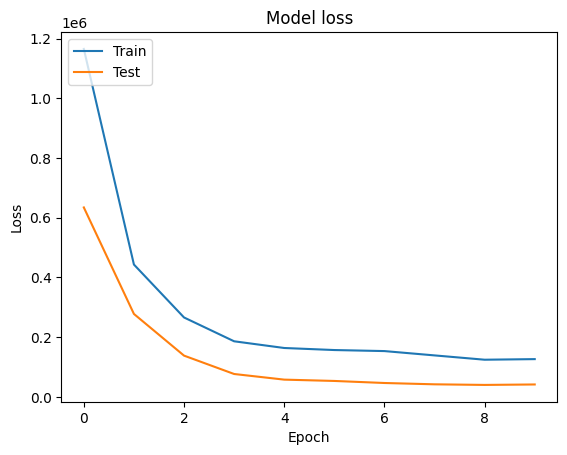

In [20]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━

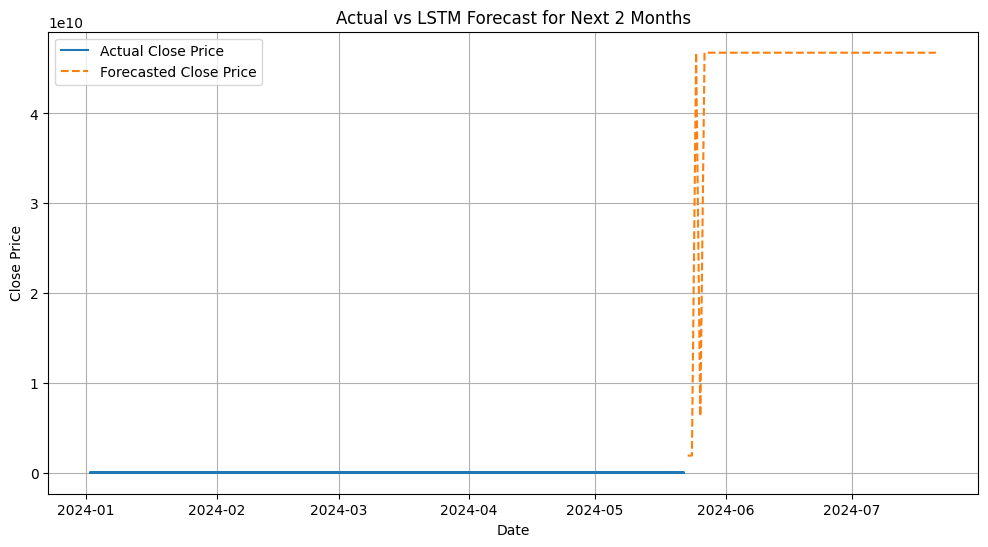

In [21]:
forecast_steps = 60
last_data_point = X_test_scaled[-1].reshape(1, 1, X_test_scaled.shape[1])

future_predictions = []
for _ in range(forecast_steps):
    # Predict the next day's close
    next_day_prediction = model.predict(last_data_point)
    future_predictions.append(next_day_prediction[0, 0])
    
    # Prepare the next input sample by appending the prediction at the end
    next_day_prediction_reshaped = next_day_prediction.reshape(1, 1, 1)
    next_data_point = np.concatenate([last_data_point, next_day_prediction_reshaped], axis=2)
    next_data_point = next_data_point[:, :, 1:]  # shift the window by 1
    last_data_point = next_data_point[:, :, :X_test_scaled.shape[1]]

# Convert the list of predictions to array and inverse transform them
future_predictions = np.array(future_predictions).reshape(-1, 1)
dummy_array = np.zeros((len(future_predictions), X_test_scaled.shape[1]-1))
future_preds_with_dummy = np.concatenate([future_predictions, dummy_array], axis=1)
future_preds_with_dummy = np.clip(future_preds_with_dummy, scaler.data_min_, scaler.data_max_)
# Here, we assume the value to be predicted corresponds to the first column
future_predictions_transformed = scaler.inverse_transform(future_preds_with_dummy)
forecasted_close = future_predictions_transformed[:, 0]

# Create future dates starting from the last date in df_2024
last_date = df_2024['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)

# Build a DataFrame with forecast data
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close': forecasted_close.flatten()
})

# Plot the actual trend and the forecasted trend
plt.figure(figsize=(12,6))
plt.plot(df_2024['Date'], df_2024['Close'], label='Actual Close Price')
plt.plot(forecast_df['Date'], forecast_df['Predicted_Close'], label='Forecasted Close Price', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs LSTM Forecast for Next 2 Months')
plt.legend()
plt.grid(True)
plt.show()

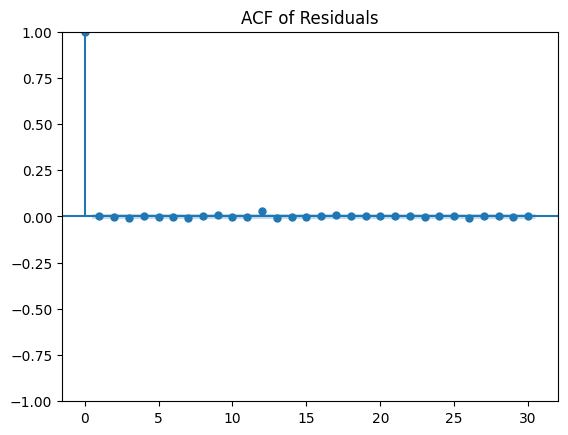

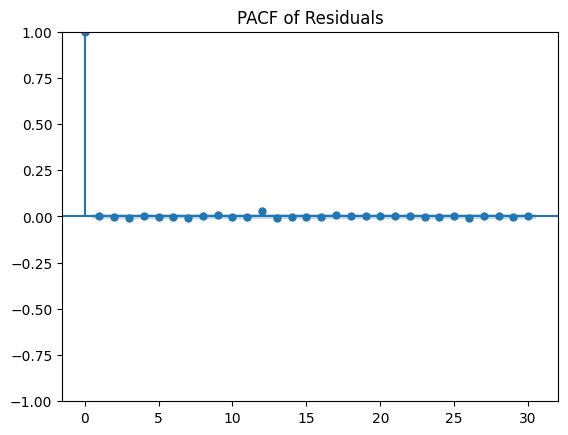

In [23]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF of the residuals
# Reshape y_pred to be 1-dimensional
residuals = y_test - y_pred.flatten()
plot_acf(residuals, lags=30)  # Adjust the number of lags as needed
plt.title('ACF of Residuals')
plt.show()

# Plot PACF of the residuals
plot_pacf(residuals, lags=30)  # Adjust the number of lags as needed
plt.title('PACF of Residuals')
plt.show()

In [24]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the residuals
result = adfuller(residuals)

# Print the test results
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if result[1] <= 0.05:
    print("Strong evidence against the null hypothesis")
    print("Reject the null hypothesis")
    print("Data is stationary")
else:
    print("Weak evidence against the null hypothesis")
    print("Fail to reject the null hypothesis")
    print("Data is non-stationary")

ADF Statistic: -142.125971
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Strong evidence against the null hypothesis
Reject the null hypothesis
Data is stationary


In [25]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare data for Prophet
df_prophet = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Split data into training and testing sets
train_prophet = df_prophet[:-30]
test_prophet = df_prophet[-30:]

# Initialize and fit the Prophet model
model = Prophet()
model.fit(train_prophet)

# Create future dataframe for predictions
future = model.make_future_dataframe(periods=len(test_prophet))

# Make predictions
forecast = model.predict(future)

# Evaluate the model
y_true = test_prophet['y'].values
y_pred = forecast['yhat'][-len(test_prophet):].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)


print("Prophet Model Evaluation")
print("------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

00:26:45 - cmdstanpy - INFO - Chain [1] start processing
00:26:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Evaluation
------------------------
Mean Absolute Error (MAE): 319.0868277773322
Mean Squared Error (MSE): 111792.82476095813
Root Mean Squared Error (RMSE): 334.35434012579844
R-squared (R2): -33289.93962606081


In [26]:
# Visualize the forecast
plot_plotly(model, forecast)

# Visualize the model components
plot_components_plotly(model, forecast)

In [27]:
# Extract predictions for test period
preds = forecast[forecast['ds'].isin(test_prophet['ds'])][['ds', 'yhat']]
y_true = test_prophet['y'].values
y_pred = preds['yhat'].values

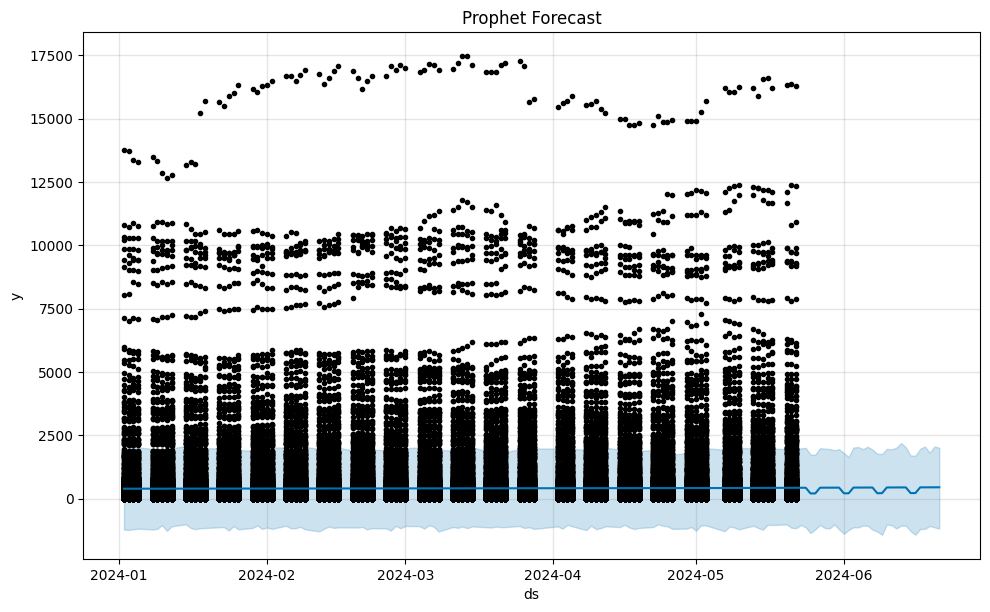

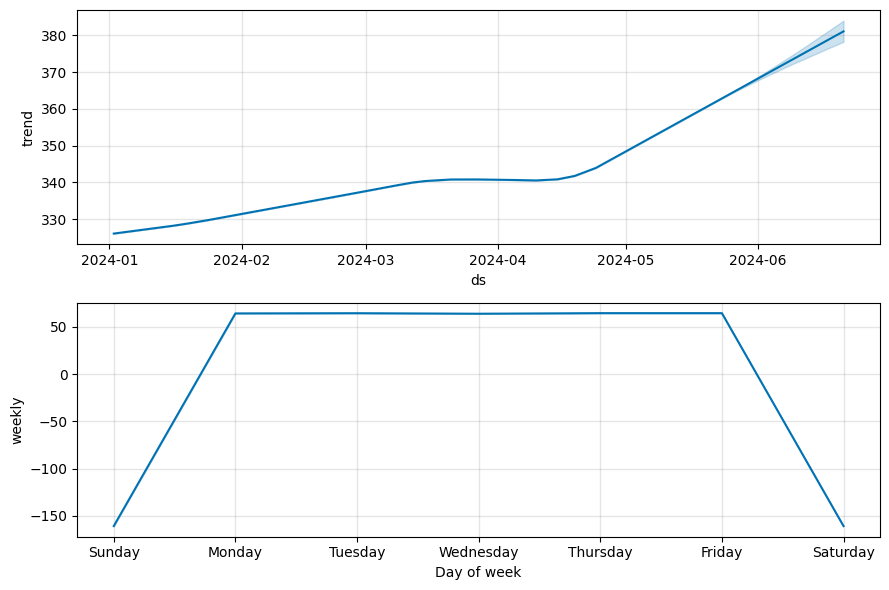

In [28]:
# Visualization
fig1 = model.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [29]:
# Interactive plot (requires plotly)
plot_plotly(model, forecast)

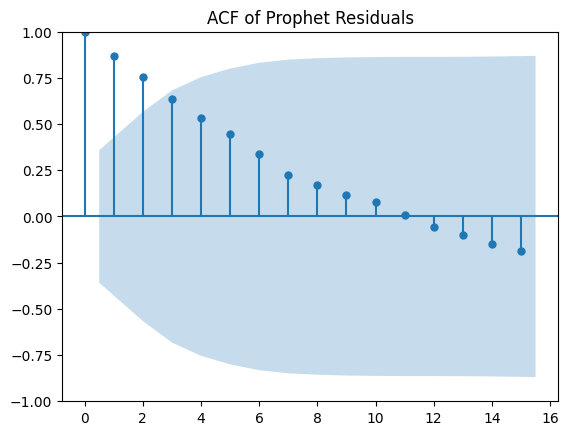

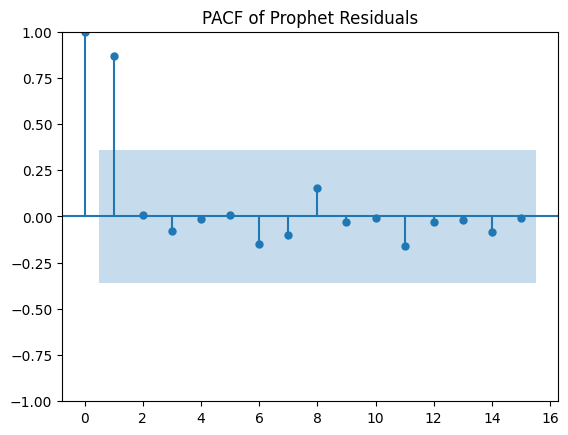

In [30]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Calculate residuals for Prophet model
residuals_prophet = y_true - y_pred

# Calculate the maximum allowed lags
max_lags = len(residuals_prophet) // 2

# Plot ACF of the residuals from Prophet model
plot_acf(residuals_prophet, lags=min(29, max_lags))
plt.title('ACF of Prophet Residuals')
plt.show()

# Plot PACF of the residuals from Prophet model
plot_pacf(residuals_prophet, lags=min(29, max_lags))
plt.title('PACF of Prophet Residuals')
plt.show()

In [31]:
# Calculate residuals for Prophet model
residuals_prophet = y_true - y_pred

# Perform the ADF test on the residuals from the Prophet model
result_prophet = adfuller(residuals_prophet)

# Print the test results
print('ADF Statistic (Prophet): %f' % result_prophet[0])
print('p-value (Prophet): %f' % result_prophet[1])
print('Critical Values (Prophet):')
for key, value in result_prophet[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if result_prophet[1] <= 0.05:
    print("Strong evidence against the null hypothesis (Prophet)")
    print("Reject the null hypothesis (Prophet)")
    print("Data is stationary (Prophet)")
else:
    print("Weak evidence against the null hypothesis (Prophet)")
    print("Fail to reject the null hypothesis (Prophet)")
    print("Data is non-stationary (Prophet)")

ADF Statistic (Prophet): 0.279182
p-value (Prophet): 0.976369
Critical Values (Prophet):
	1%: -3.689
	5%: -2.972
	10%: -2.625
Weak evidence against the null hypothesis (Prophet)
Fail to reject the null hypothesis (Prophet)
Data is non-stationary (Prophet)


In [32]:
model_arima = ARIMA(close, order=(5, 1, 0))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:               101335
Model:                 ARIMA(5, 1, 0)   Log Likelihood             -666794.861
Date:                Mon, 14 Apr 2025   AIC                        1333601.722
Time:                        00:27:43   BIC                        1333658.879
Sample:                             0   HQIC                       1333619.057
                             - 101335                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0132      0.001     -9.040      0.000      -0.016      -0.010
ar.L2          0.0035      0.002      1.388      0.165      -0.001       0.008
ar.L3         -0.0039      0.009     -0.429      0.6

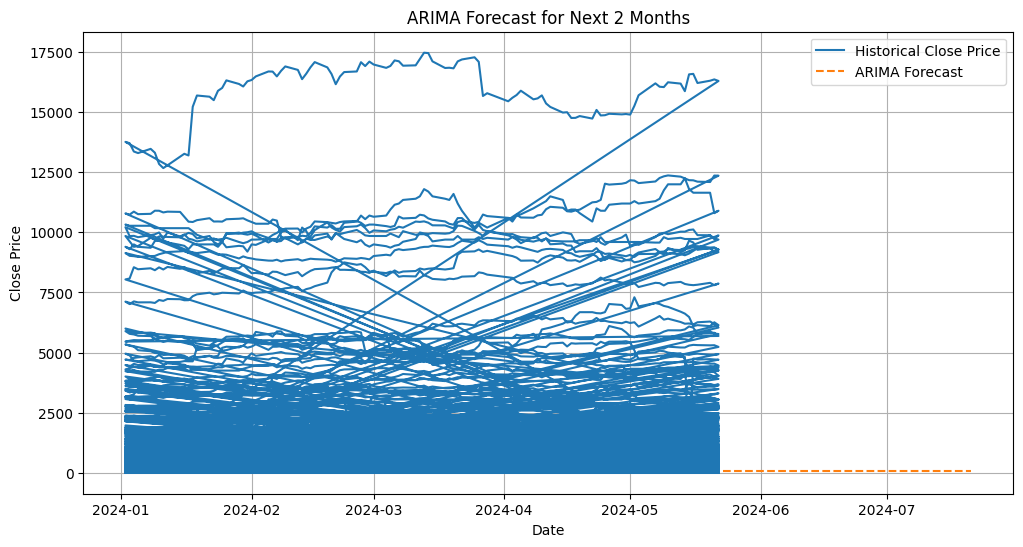

In [34]:
forecast_steps = 60  # Forecast for next 60 days (approx. 2 months)
forecast_arima = model_arima_fit.forecast(steps=forecast_steps)

last_date = df['Date'].iloc[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)

forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast': forecast_arima
})

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Historical Close Price')
plt.plot(forecast_df['Date'], forecast_df['Forecast'], label='ARIMA Forecast', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('ARIMA Forecast for Next 2 Months')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
df.head()

,Unnamed: 0,Date,Ticker,Company_Name,Open,High,Low,Close,Adj Close,Volume
0,433,2024-01-02,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.790,4.50,4.6,4.6,13557.0
1,434,2024-01-03,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.600,4.60,4.6,4.6,0.0
2,435,2024-01-04,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.700,4.59,4.6,4.6,37422.0
3,436,2024-01-05,1SN.L,FIRST TIN PLC ORD GBP0.001,4.6,4.575,4.50,4.5,4.5,225823.0
4,437,2024-01-08,1SN.L,FIRST TIN PLC ORD GBP0.001,4.5,4.530,4.34,4.5,4.5,154905.0


Forecasted Close prices for next 6 months:
             Date    Forecast
101335 2024-05-31  421.031270
101336 2024-06-30  407.596274
101337 2024-07-31  404.358776
101338 2024-08-31  422.860282
101339 2024-09-30  430.798889
101340 2024-10-31  429.666010


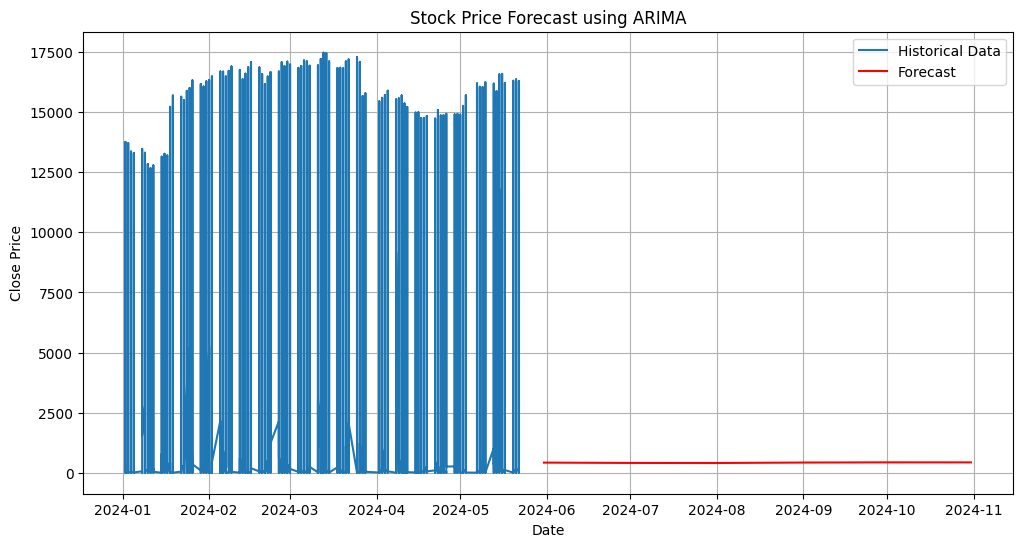

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import datetime, timedelta

required_columns = ['Date', 'Close']
available_columns = df.columns.tolist()

# Fit ARIMA model
try:
    # Set Date as index if not already
    if not isinstance(df.index, pd.DatetimeIndex):
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
    
    # Ensure the data is properly sorted by index
    df = df.sort_index()
    
    model = SARIMAX(df['Close'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    results = model.fit()

    # Generate future dates for forecasting
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + timedelta(days=1), 
                               periods=6, 
                               freq='M')

    # Make predictions for next 6 months
    forecast = results.forecast(steps=6)

    # Create DataFrame with forecasted values
    forecast_df = pd.DataFrame({
        'Date': future_dates,
        'Forecast': forecast
    })

    # Print the forecasted values
    print("Forecasted Close prices for next 6 months:")
    print(forecast_df)

    # Plot the results
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Close'], label='Historical Data')
    plt.plot(forecast_df['Date'], forecast_df['Forecast'], label='Forecast', color='red')
    plt.title('Stock Price Forecast using ARIMA')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()
except Exception as e:
    print(f"Error occurred: {e}")
    print("Please ensure the 'Date' column is in datetime format and the data is sorted by date.")
    print("Also, check if the required columns are present in the DataFrame.")

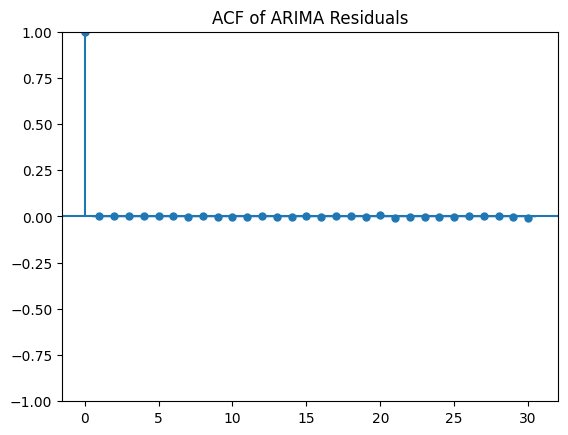

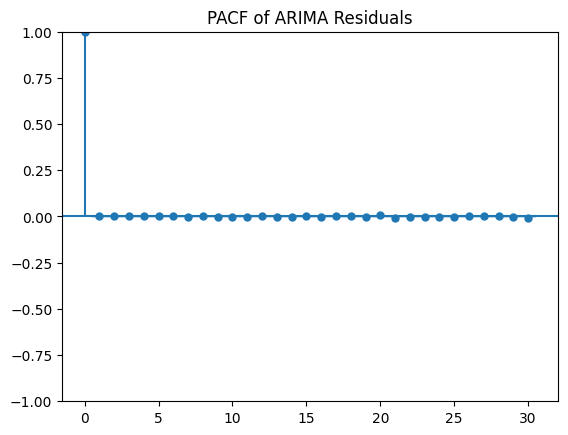

In [26]:
import matplotlib.pyplot as plt
# Plot ACF and PACF for the ARIMA model residuals
residuals_arima = model_arima_fit.resid

plot_acf(residuals_arima, lags=30)
plt.title('ACF of ARIMA Residuals')
plt.show()

plot_pacf(residuals_arima, lags=30)
plt.title('PACF of ARIMA Residuals')
plt.show()

In [27]:
# Perform the ADF test on the ARIMA model residuals
result_arima = adfuller(residuals_arima)

# Print the test results
print('ADF Statistic (ARIMA): %f' % result_arima[0])
print('p-value (ARIMA): %f' % result_arima[1])
print('Critical Values (ARIMA):')
for key, value in result_arima[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if result_arima[1] <= 0.05:
    print("Strong evidence against the null hypothesis (ARIMA)")
    print("Reject the null hypothesis (ARIMA)")
    print("Data is stationary (ARIMA)")
else:
    print("Weak evidence against the null hypothesis (ARIMA)")
    print("Fail to reject the null hypothesis (ARIMA)")
    print("Data is non-stationary (ARIMA)")

ADF Statistic (ARIMA): -40.785256
p-value (ARIMA): 0.000000
Critical Values (ARIMA):
	1%: -3.430
	5%: -2.862
	10%: -2.567
Strong evidence against the null hypothesis (ARIMA)
Reject the null hypothesis (ARIMA)
Data is stationary (ARIMA)


In [28]:
# Calculate the evaluation metrics
mae_arima = mean_absolute_error(y_test, model_arima_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1))
mse_arima = mean_squared_error(y_test, model_arima_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1))
rmse_arima = np.sqrt(mse_arima)
r2_arima = r2_score(y_test, model_arima_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1))

print("ARIMA Model Evaluation")
print("------------------------")
print(f"Mean Absolute Error (MAE): {mae_arima}")
print(f"Mean Squared Error (MSE): {mse_arima}")
print(f"Root Mean Squared Error (RMSE): {rmse_arima}")
print(f"R-squared (R2): {r2_arima}")

ARIMA Model Evaluation
------------------------
Mean Absolute Error (MAE): 135.51226483994924
Mean Squared Error (MSE): 352573.24737342127
Root Mean Squared Error (RMSE): 593.7787865640042
R-squared (R2): 0.5705871046841311


In [29]:
!pip install arch -q

import arch

# GARCH(1,1) model
model_garch = arch.arch_model(residuals, p=1, q=1)
results_garch = model_garch.fit(disp='off')
results_garch.summary()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 24.4 MB/s eta 0:00:00


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -124243.
Distribution:                  Normal   AIC:                           248493.
Method:            Maximum Likelihood   BIC:                           248525.
                                        No. Observations:                20263
Date:                Mon, Apr 07 2025   Df Residuals:                    20262
Time:                        18:19:40   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu           -35.5422     24.151     -1.472      0.141 [-82.878, 11.794]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega       1271.1134   2541.156      0.500      0.617 [-3.709e+03,6.252e+03]
alpha[1]       0.2132      0.108      1.969  4.890e-02    [1.025e-03,  0.425]
beta[1]        0.7868      0.155      5.071  3.948e-07      [  0.483,  1.091]
=============================================================================

Covariance estimator: robust
"""

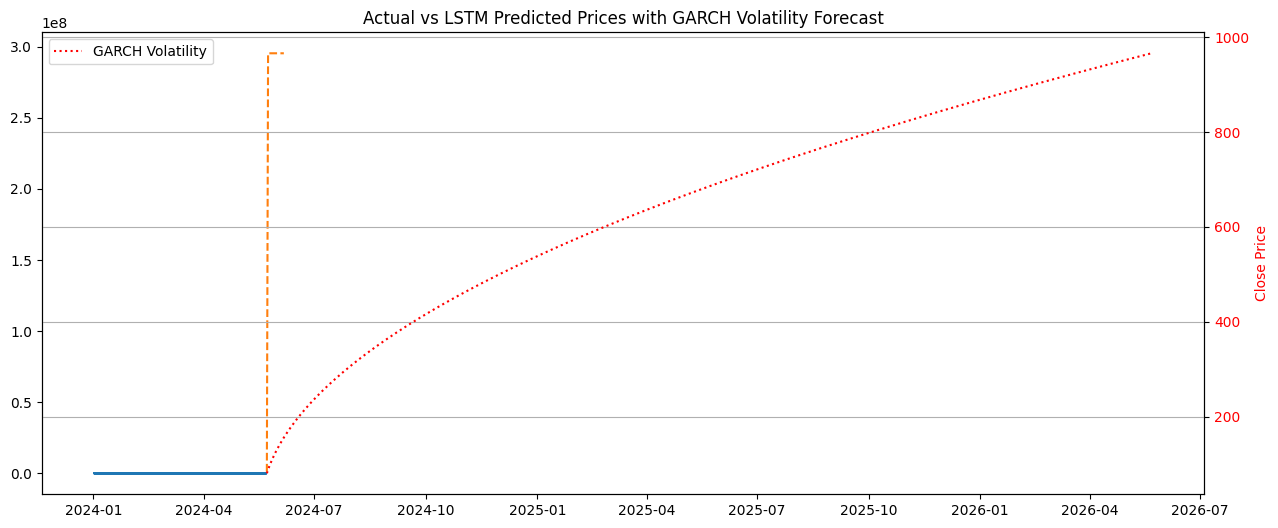

In [30]:
# Forecast volatility using GARCH
forecast_horizon = 730  # Number of days to forecast
forecast_garch = results_garch.forecast(horizon=forecast_horizon)
volatility_forecast = np.sqrt(forecast_garch.variance.values[-1, :])

# Create dates for the forecast
last_date = df['Date'].iloc[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon)

# Plotting actual, LSTM predicted and GARCH volatility forecast
plt.figure(figsize=(15, 6))

plt.plot(df['Date'], df['Close'], label='Actual Close Price')
plt.plot(future_df['Date'], future_df['Predicted_Close'], label='Arch and Garch Predicted Close Price', linestyle='--')

# Plot the volatility forecast with a different y-axis
ax2 = plt.gca().twinx()
ax2.plot(forecast_dates, volatility_forecast, label='GARCH Volatility', color='red', linestyle=':')
ax2.set_ylabel('Volatility', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs LSTM Predicted Prices with GARCH Volatility Forecast')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [31]:
# ARCH model
model_arch = arch.arch_model(residuals, p=1, o=0, q=0)  # Simple ARCH(1)
results_arch = model_arch.fit(disp='off')
print(results_arch.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -125588.
Distribution:                  Normal   AIC:                           251183.
Method:            Maximum Likelihood   BIC:                           251206.
                                        No. Observations:                20263
Date:                Mon, Apr 07 2025   Df Residuals:                    20262
Time:                        18:19:41   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu           -15.5219     34.872     -0.445      0.656 [-83.869, 52.82

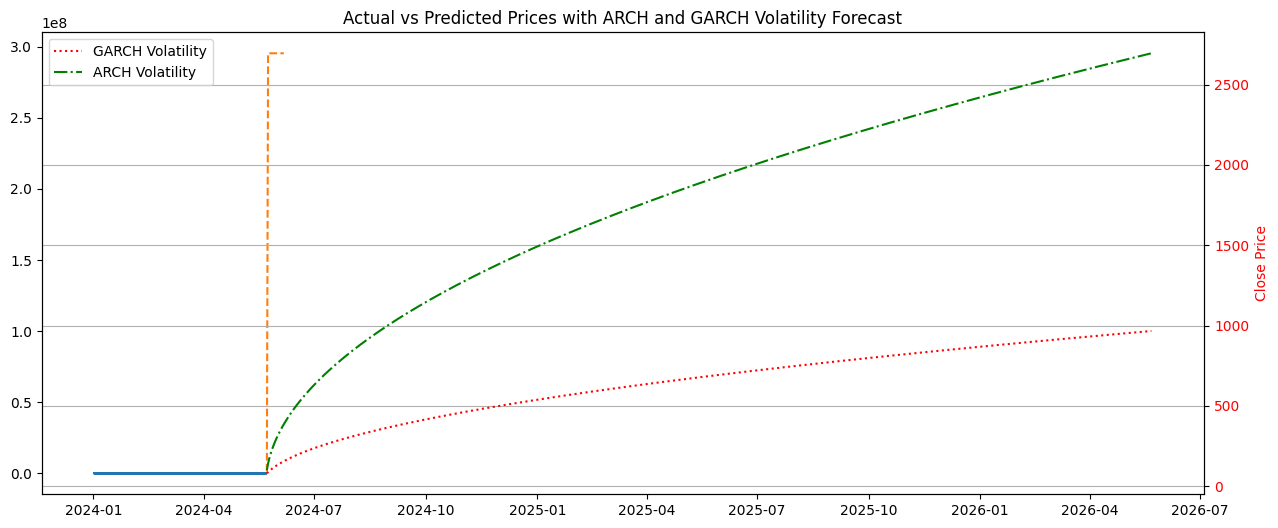

In [32]:
# Forecast volatility using ARCH
forecast_arch = results_arch.forecast(horizon=forecast_horizon)
volatility_forecast_arch = np.sqrt(forecast_arch.variance.values[-1, :])

# Plotting actual, LSTM predicted, and ARCH and GARCH volatilities
plt.figure(figsize=(15, 6))

plt.plot(df['Date'], df['Close'], label='Actual Close Price')
plt.plot(future_df['Date'], future_df['Predicted_Close'], label='LSTM Predicted', linestyle='--')

# Plotting GARCH volatility
ax2 = plt.gca().twinx()
ax2.plot(forecast_dates, volatility_forecast, label='GARCH Volatility', color='red', linestyle=':')
ax2.set_ylabel('GARCH Volatility', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Plotting ARCH volatility on the same secondary axis
ax2.plot(forecast_dates, volatility_forecast_arch, label='ARCH Volatility', color='green', linestyle='-.')
ax2.set_ylabel('Volatility', color='red')
ax2.tick_params(axis='y', labelcolor='red')


plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Prices with ARCH and GARCH Volatility Forecast')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [33]:
y_test_subset = y_test[-len(future_df['Predicted_Close']):]

# Replace NaN values in future_df['Predicted_Close'] with 0 (or another appropriate value)
future_df['Predicted_Close'] = future_df['Predicted_Close'].fillna(0)

# Calculate the evaluation metrics using the aligned subsets
mae_arch_garch = mean_absolute_error(y_test_subset, future_df['Predicted_Close'])
mse_arch_garch = mean_squared_error(y_test_subset, future_df['Predicted_Close'])
rmse_arch_garch = np.sqrt(mse_arch_garch)
mape_arch_garch = np.mean(np.abs((y_test_subset - future_df['Predicted_Close']) / y_test_subset)) * 100
r2_arch_garch = r2_score(y_test_subset, future_df['Predicted_Close'])

print("ARCH and GARCH Model Evaluation")
print("------------------------")
print(f"Mean Absolute Error (MAE): {mae_arch_garch}")
print(f"Mean Squared Error (MSE): {mse_arch_garch}")
print(f"Root Mean Squared Error (RMSE): {rmse_arch_garch}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_arch_garch}")
print(f"R-squared (R2): {r2_arch_garch}")

ARCH and GARCH Model Evaluation
------------------------
Mean Absolute Error (MAE): 5666888.901175586
Mean Squared Error (MSE): 1673475181683948.8
Root Mean Squared Error (RMSE): 40908130.99719845
Mean Absolute Percentage Error (MAPE): nan
R-squared (R2): -86113091393.97694


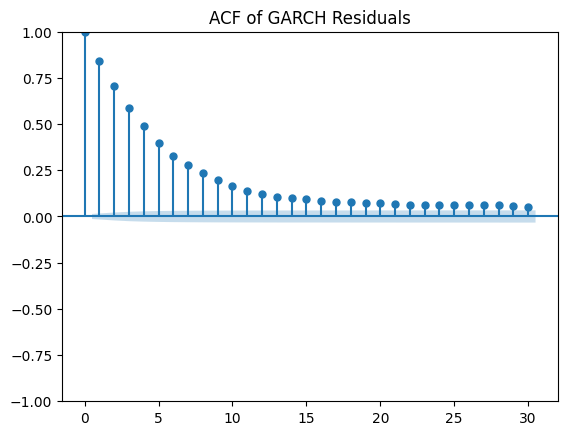

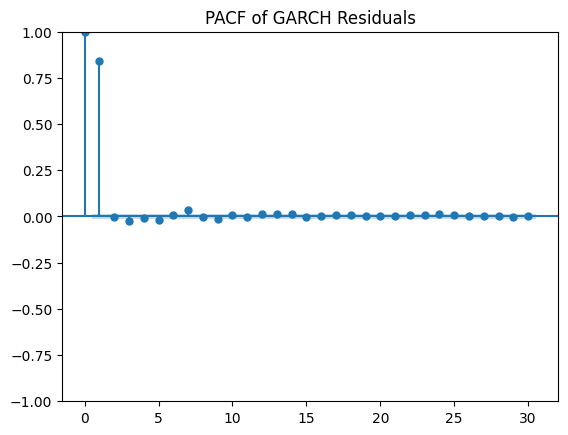

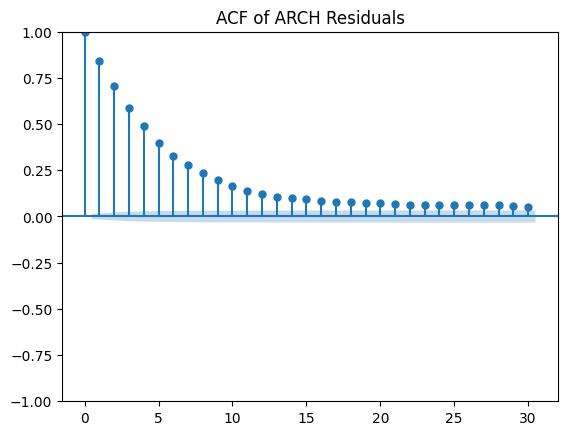

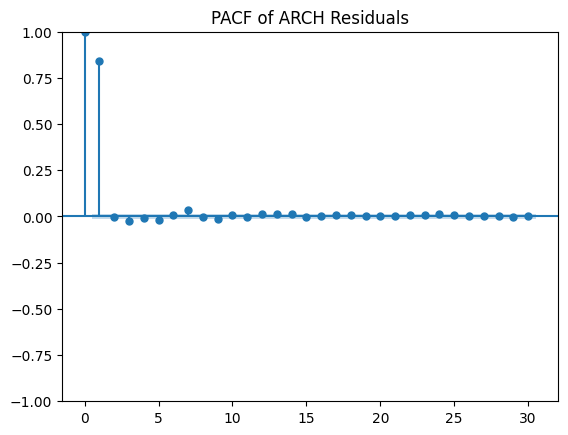

In [34]:
# Plot ACF and PACF for the GARCH model residuals
residuals_garch = results_garch.resid

plot_acf(residuals_garch, lags=30)
plt.title('ACF of GARCH Residuals')
plt.show()

plot_pacf(residuals_garch, lags=30)
plt.title('PACF of GARCH Residuals')
plt.show()

# Plot ACF and PACF for the ARCH model residuals
residuals_arch = results_arch.resid

plot_acf(residuals_arch, lags=30)
plt.title('ACF of ARCH Residuals')
plt.show()

plot_pacf(residuals_arch, lags=30)
plt.title('PACF of ARCH Residuals')
plt.show()